# The Bouguer anomaly and the referencing layer

Geometry inversions of a complete Bouguer anomaly (CBGA) for a basement surface hide a subtle bookkeeping question: the anomaly's source is the low-density basin fill between the **basement surface and the ground**, but the inversion models prisms between the basement surface and a flat **reference level (zref)**.
Those are not the same body of rock.
The difference between them - a fixed, terrain-shaped layer between zref and the ground, which we call the **referencing layer** - is easy to leave out by accident.

Left out, it does not just shift the anomaly by a constant: it leaks the shape of the topography into the residual, and from there into the inverted basement, producing terrain-correlated artifacts that look like geology.
This notebook explains the bookkeeping with cross-section sketches, demonstrates the artifact on a synthetic model, and shows the two-line fix.

Related notebooks: [estimating the regional field](../tutorial/07_estimating_regional_field.ipynb) (where the referencing layer's long wavelengths can end up), [reference level optimization](../tutorial/06_reference_level_optimization.ipynb) (with the referencing layer included, the inversion is largely insensitive to zref), and [recovering a fault-bounded basin](fault_bounded_basin.ipynb) (a full workflow this correction slots into).

## Import packages

In [13]:
import harmonica as hm
import matplotlib.pyplot as plt
import numpy as np
import scipy
import verde as vd
import xarray as xr

import invert4geom

## What masses does a Bouguer anomaly contain?

The Bouguer and terrain corrections remove the attraction of all rock between the vertical datum and the ground surface, at a uniform reduction density (say 2,670 kg/m3, matching the basement).
Whatever anomalous mass is left is measured *relative to that filled-in background*.
In a sediment-over-basement setting the only local anomalous body is therefore the basin fill: between the basement surface and the ground the real density is ~2,270 kg/m3, the background assumed 2,670 kg/m3, so the CBGA sees a **-400 kg/m3 layer from the basement surface up to the ground**:

    CBGA = f(-dp, basement -> ground) + regional

where `f(p, a -> b)` is the gravity of a layer of density `p` between surfaces `a` and `b`, signed so that swapping `a` and `b` flips the sign, and `dp` is the (positive) density contrast.

This "only the fill" statement is load-bearing and rests on one assumption: **the Bouguer reduction density equals the basement density** (both 2,670 here).
If they differ, the basement rock is itself anomalous against the reduction-density background, adding a second body to the anomaly; you would then either reduce at the basement density (recovering this picture) or carry an extra basement term.
We also assume the fill and basement densities are laterally uniform.

A geometry inversion does not model that body.
It models prisms between a flat reference level and the basement surface: `+dp` where the basement is above zref, `-dp` where it is below, which is the signed layer `f(+dp, zref -> basement)`.
Splitting the true source at zref:

    f(-dp, basement -> ground) = f(+dp, zref -> basement) + f(-dp, zref -> ground)
                                 -------------------------   ------------------------
                                 the inversion's model       the referencing layer

The first term is exactly what [create_model](../api/generated/invert4geom.create_model.rst) builds and the inversion adjusts.
The second term is fixed: it depends only on zref, the ground surface and the density contrast - not on the basement at all - so it can be forward modelled once and subtracted from the observed anomaly before inverting.

## A cross-section sketch

First the setting: rugged ground, a basin of low-density fill, and basement everywhere else at the reduction density.

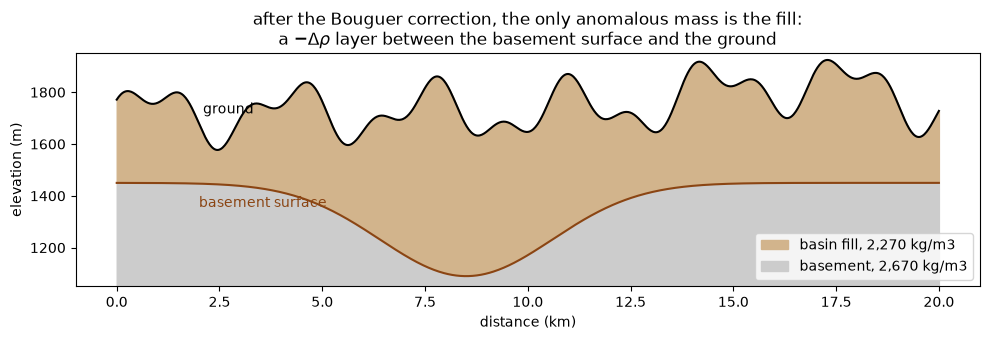

In [14]:
x_p = np.linspace(0, 20e3, 800)
# rugged ground over a smooth basement (flat background with a basin)
ground_p = (
    1720
    + 90 * np.sin(2 * np.pi * x_p / 3.4e3)
    + 55 * np.sin(2 * np.pi * x_p / 1.55e3 + 1.2)
    + 120 * np.exp(-((x_p - 16.5e3) ** 2) / (2 * 2.3e3**2))
)
basement_bg_p = 1450
basement_p = basement_bg_p - 360 * np.exp(-((x_p - 8.5e3) ** 2) / (2 * 2.1e3**2))
zref_sketch = basement_bg_p

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.fill_between(
    x_p / 1e3,
    basement_p,
    ground_p,
    color="tan",
    label="basin fill, 2,270 kg/m3",
)
ax.fill_between(
    x_p / 1e3,
    1050,
    basement_p,
    color="0.8",
    label="basement, 2,670 kg/m3",
)
ax.plot(x_p / 1e3, ground_p, "k", lw=1.5)
ax.plot(x_p / 1e3, basement_p, color="saddlebrown", lw=1.5)
ax.annotate("ground", (2.1, ground_p[80] + 40))
ax.annotate("basement surface", (2.0, basement_p[80] - 90), color="saddlebrown")
ax.set_ylim(1050, 1950)
ax.set_xlabel("distance (km)")
ax.set_ylabel("elevation (m)")
ax.set_title(
    "after the Bouguer correction, the only anomalous mass is the fill:\n"
    "a $-\\Delta\\rho$ layer between the basement surface and the ground"
)
ax.legend(loc="lower right")
plt.tight_layout()

Now the split.
The top panel is the true source.
The middle panel is the referencing layer: the same $-\Delta\rho$, but between zref and the ground, ignoring the basement entirely.
The bottom panel is the model the inversion adjusts: $+\Delta\rho$ between zref and the basement, negative where the basement drops below zref.
Here we have set zref at the background basement level, so outside the basin the basement sits at zref and there is nothing for the model to hold - the entire signal there is the referencing layer, and the model is just the basin.
Adding the bottom two panels reproduces the top one: wherever both the referencing layer and the model occupy the interval between zref and the basement, their $-\Delta\rho$ and $+\Delta\rho$ cancel, and what survives is exactly the fill between the basement and the ground.

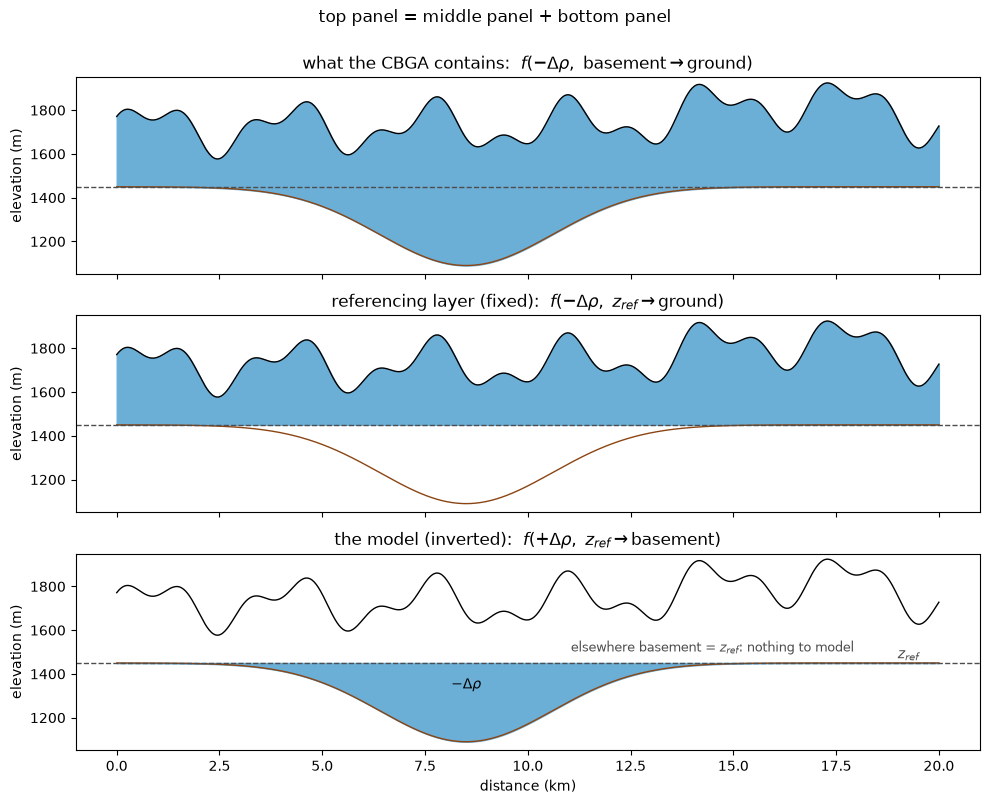

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True, sharey=True)

neg = "#6baed6"

ax = axes[0]
ax.fill_between(x_p / 1e3, basement_p, ground_p, color=neg)
ax.set_title(
    "what the CBGA contains:  $f(-\\Delta\\rho,\\ \\mathrm{basement} \\to \\mathrm{ground})$"
)

ax = axes[1]
ax.fill_between(x_p / 1e3, zref_sketch, ground_p, color=neg)
ax.set_title(
    "referencing layer (fixed):  $f(-\\Delta\\rho,\\ z_{ref} \\to \\mathrm{ground})$"
)

ax = axes[2]
ax.fill_between(
    x_p / 1e3,
    zref_sketch,
    basement_p,
    where=basement_p < zref_sketch,
    color=neg,
)
ax.annotate("$-\\Delta\\rho$", (8.5, 1330), ha="center")
ax.annotate(
    "elsewhere basement = $z_{ref}$: nothing to model",
    (14.5, 1500),
    ha="center",
    fontsize=9,
    color="0.3",
)
ax.set_title(
    "the model (inverted):  $f(+\\Delta\\rho,\\ z_{ref} \\to \\mathrm{basement})$"
)

for ax in axes:
    ax.plot(x_p / 1e3, ground_p, "k", lw=1)
    ax.plot(x_p / 1e3, basement_p, color="saddlebrown", lw=1)
    ax.axhline(zref_sketch, color="0.3", ls="--", lw=1)
    ax.set_ylabel("elevation (m)")
axes[0].set_ylim(1050, 1950)
axes[2].annotate("$z_{ref}$", (19.0, zref_sketch + 20), color="0.3")
axes[2].set_xlabel("distance (km)")
fig.suptitle("top panel = middle panel + bottom panel", y=1.0)
plt.tight_layout()

## Why leaving it out hurts

The referencing layer is shaped by the terrain.
Its long-wavelength part *can* be absorbed by the regional - but only if the regional you estimate is flexible enough to fit it (a low-pass, an upward continuation, a trend). A constant or low-order regional, like the one used in the demonstration below, cannot, and leaves the broad terrain swell in the residual too.
Its short-wavelength part - ridges and valleys at a few km scale - can be absorbed by no smooth regional at all: it stays in the residual, and the inversion converts it into basement relief at roughly $1 / (2 \pi G \Delta\rho) \approx 60$ m per mGal (for $\Delta\rho$ = 400 kg/m3, an infinite-slab upper bound - at few-km wavelengths the true conversion is somewhat smaller).
The safe move is not to rely on the regional for any of it, but to subtract the whole referencing layer explicitly.

The direction of the artifact follows from the sign.
The referencing layer has density $-\Delta\rho$, so over a hill - where the layer from zref up to the ground is thicker - its gravity is *more negative*.
Left in the misfit, that extra low is fit by the inversion adding negative-density mass, i.e. deepening the basement.
So the recovered basement **anti-correlates with the topography: lows (deeper basement) under hills, highs (shallower basement) under valleys**, everywhere - including where basement is exposed and demonstrably flat against the ground.
With a few hundred meters of local relief the layer's texture reaches a few mGal, i.e. one to two hundred meters of spurious basement relief.
In rugged terrain this can be the largest error source in the whole workflow.

## A synthetic demonstration

A 15 x 15 km area with rugged terrain (~200 m of relief at km scales) over a more realistic basement than a single smooth basin:

- a central sedimentary basin flanked by two basement highs (horsts) that **rise to the surface and outcrop** - so the sediment fill goes to zero there, and the basement is *known* (it is the ground) at the outcrops,
- short-wavelength **roughness** on the basement, so it is not perfectly resolvable - any leftover error is a mix of the referencing-layer artifact and a genuine resolution limit, and we will use the terrain *correlation* to separate the two,
- a smooth **regional field** (a ~28 mGal planar tilt from a deep source) added on top of the basin signal, so the inversion has to estimate and remove a real regional, not just a constant.

The basement highs are placed symmetrically so the basement has no large-scale planar tilt of its own - otherwise a low-order regional could not tell the deep regional from the basement's own slope (the classic regional-residual ambiguity). The gravity is observed on a drape 80 m above the ground (an airborne-style acquisition).

In [16]:
spacing = 250
region = (0, 15e3, 0, 15e3)
grid_coords = vd.grid_coordinates(spacing=spacing, region=region)
easting, northing = grid_coords
x_km, y_km = easting / 1e3, northing / 1e3

density_contrast = 400
zref = 1650  # near the mean basement, so the regional's DC term costs no absolute level

# rugged ground: band-limited noise plus a gentle swell
rng = np.random.default_rng(42)
gtex = scipy.ndimage.gaussian_filter(rng.normal(size=easting.shape), sigma=5)
gtex *= 90 / gtex.std()
ground = 1900 + gtex + 60 * np.sin(2 * np.pi * (x_km + y_km) / 20)
ground = vd.make_xarray_grid(grid_coords, data=ground, data_names="upward").upward

# rougher basement, no large-scale planar tilt: a central basin flanked by two
# symmetric basement highs, a ridge, and short-wavelength texture
btex = scipy.ndimage.gaussian_filter(rng.normal(size=easting.shape), sigma=3)
btex *= 20 / btex.std()
horsts = 620 * (
    np.exp(-(((x_km - 2.8) ** 2 / (2 * 1.3**2)) + ((y_km - 7.5) ** 2 / (2 * 2.6**2))))
    + np.exp(
        -(((x_km - 12.2) ** 2 / (2 * 1.3**2)) + ((y_km - 7.5) ** 2 / (2 * 2.6**2)))
    )
)
basement = (
    1700
    - 230
    * np.exp(-(((x_km - 7.5) ** 2 / (2 * 2.6**2)) + ((y_km - 6.5) ** 2 / (2 * 3.0**2))))
    + horsts
    + 100
    * np.exp(
        -(((x_km - 9.0) ** 2 / (2 * 1.2**2)) + ((y_km - 11.0) ** 2 / (2 * 1.6**2)))
    )
    + btex
)
basement = vd.make_xarray_grid(grid_coords, data=basement, data_names="upward").upward
# where the basement rises above the ground it outcrops: clip it to the ground there
basement = basement.where(basement < ground, ground)
outcrop = (ground - basement) < 1.0

# smooth regional gravity field from a deep source: a planar tilt, ~28 mGal across
regional = 1.1 * (x_km - 7.5) - 0.8 * (y_km - 7.5)
regional = vd.make_xarray_grid(grid_coords, data=regional, data_names="g").g

print(f"ground:    {float(ground.min()):.0f} to {float(ground.max()):.0f} m")
print(f"basement:  {float(basement.min()):.0f} to {float(basement.max()):.0f} m")
print(f"max sediment thickness: {float((ground - basement).max()):.0f} m")
print(f"basement outcrops over {100 * float(outcrop.mean()):.0f}% of the area")

ground:    1632 to 2177 m
basement:  1483 to 1999 m
max sediment thickness: 491 m
basement outcrops over 24% of the area


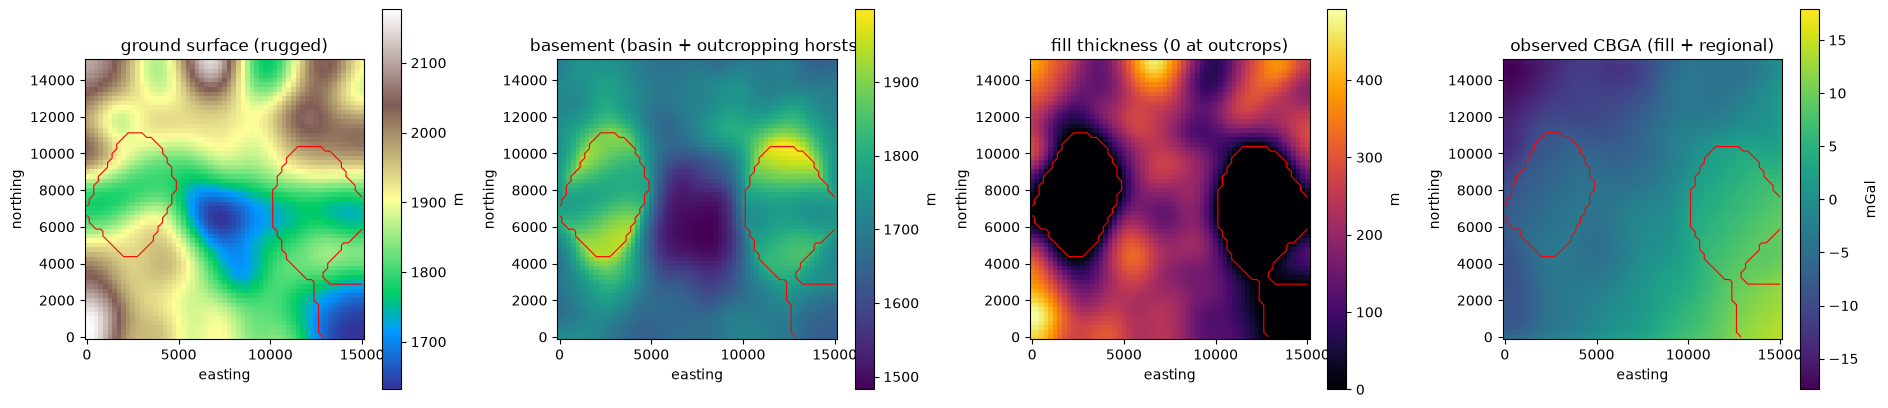

In [17]:
# the local anomaly is the fill body (basement -> ground, -dp); the observed CBGA
# is that plus the deep regional
fill_prisms = hm.prism_layer(
    coordinates=(ground.easting.values, ground.northing.values),
    surface=ground,
    reference=basement,
    properties={"density": xr.full_like(ground, -density_contrast)},
)

obs_height = ground + 80
local = fill_prisms.prism_layer.gravity(
    coordinates=(easting, northing, obs_height.values),
    field="g_z",
)
local = vd.make_xarray_grid(grid_coords, data=local, data_names="g").g
observed = (local + regional).rename("gravity_anomaly")


def mark_outcrop(ax):
    ax.contour(
        easting, northing, outcrop.values, levels=[0.5], colors="red", linewidths=0.8
    )


fig, axes = plt.subplots(1, 4, figsize=(19, 4.2))
ground.plot(ax=axes[0], cmap="terrain", cbar_kwargs={"label": "m"})
axes[0].set_title("ground surface (rugged)")
basement.plot(ax=axes[1], cmap="viridis", cbar_kwargs={"label": "m"})
axes[1].set_title("basement (basin + outcropping horsts)")
(ground - basement).plot(ax=axes[2], cmap="inferno", cbar_kwargs={"label": "m"})
axes[2].set_title("fill thickness (0 at outcrops)")
observed.plot(ax=axes[3], cmap="viridis", cbar_kwargs={"label": "mGal"})
axes[3].set_title("observed CBGA (fill + regional)")
for ax in axes:
    mark_outcrop(ax)
    ax.set_aspect("equal")
plt.tight_layout()

The red contours are the basement outcrops. The observed anomaly is dominated by the smooth regional tilt; the basin low and the terrain imprint (the referencing layer) sit on top of it.

## The split is exact, and zref is only a pivot

Before inverting, verify the identity numerically, for several choices of zref.
Both terms are built with `create_model`: the model term with `+density_contrast` and the basement as its topography, the referencing layer with `-density_contrast` and the ground.
Their sum reproduces the true *local* anomaly (the fill, without the regional) to numerical precision, *for any zref*: moving zref only re-partitions mass between the two terms.
This is also why, with the referencing layer included, the choice of zref becomes a pure modelling convenience - leave it out, and the missing layer changes with zref, so the inversion result would spuriously depend on it.

In [18]:
def layer_gravity(topography, layer_zref, density):
    layer = invert4geom.create_model(
        zref=layer_zref,
        density_contrast=density,
        topography=xr.Dataset({"upward": topography}),
    )
    grav = layer.prism_layer.gravity(
        coordinates=(easting, northing, obs_height.values),
        field="g_z",
    )
    return vd.make_xarray_grid(grid_coords, data=grav, data_names="g").g


for zref_test in (1450, 1650, 1850):
    model_term = layer_gravity(basement, zref_test, density_contrast)
    ref_term = layer_gravity(ground, zref_test, -density_contrast)
    err = float(np.abs(model_term + ref_term - local).max())
    print(
        f"zref = {zref_test} m: max |model + referencing layer - fill| = {err:.2e} mGal"
    )

zref = 1450 m: max |model + referencing layer - fill| = 1.55e-12 mGal
zref = 1650 m: max |model + referencing layer - fill| = 1.61e-12 mGal
zref = 1850 m: max |model + referencing layer - fill| = 1.49e-12 mGal


## Inverting without the referencing layer

The setup: the ground is an upper confining layer, the regional is removed with a first-order **trend** (which can fit the planar deep field), and the mapped outcrops are baked into the starting model - the basement is set to the ground where it is known to crop out, and to zref elsewhere. This is the only prior used, and both inversions below share it, so the comparison is purely about the referencing layer.

The misfit handed to the inversion is the observed anomaly minus its trend - the referencing layer's terrain texture is still in it, because no smooth trend can remove it.

In [19]:
starting_basement = xr.where(outcrop, ground, float(zref))  # mapped outcrops as prior


def make_data():
    gravity = xr.Dataset({"gravity_anomaly": observed, "upward": obs_height})
    return invert4geom.create_data(gravity, buffer_width=1500)


def make_model(reference=zref):
    return invert4geom.create_model(
        zref=reference,
        density_contrast=density_contrast,
        topography=xr.Dataset({"upward": starting_basement}),
        upper_confining_layer=ground,
    )


def separate_and_invert(data, model):
    data.inv.forward_gravity(model)
    data.inv.regional_separation(method="trend", trend=1)  # removes the planar regional
    res_start = data.res.copy()
    inv = invert4geom.Inversion(
        data,
        model,
        deriv_type="finite_difference",
        solver_damping=0.002,
        adaptive_damping=True,
        revert_to_best=True,
        max_iterations=30,
        l2_norm_tolerance=float(np.sqrt(0.05)),
    )
    inv.invert(progressbar=False)
    return inv, res_start


data_without = make_data()
inv_without, res_start_without = separate_and_invert(data_without, make_model())
print(inv_without.termination_reason, f"final RMSE {inv_without.rmse:.3f} mGal")

['delta l2-norm tolerance'] final RMSE 0.229 mGal


## Inverting with the referencing layer

The fix is two lines: forward model the (zref -> ground, $-\Delta\rho$) layer with `create_model` (the negative density contrast handles ground above or below zref automatically) and subtract its gravity from the observed anomaly, *before* estimating the regional.
Here the layer shares the data grid for simplicity; with real data, build its topography from a DEM padded well beyond the gravity region. The main reason to pad is edge effects: a finite prism layer produces spurious gravity gradients at its truncation boundary, and padding pushes those out beyond the area of interest. Any long-wavelength offset that remains is then harmless - the trend absorbs it.

In [20]:
ref_layer = invert4geom.create_model(
    zref=zref,
    density_contrast=-density_contrast,
    topography=xr.Dataset({"upward": ground}),
)

data_with = make_data()
data_with.inv.forward_gravity(ref_layer, name="ref_grav")
data_with["gravity_anomaly"] = data_with.gravity_anomaly - data_with.ref_grav

inv_with, res_start_with = separate_and_invert(data_with, make_model())
print(inv_with.termination_reason, f"final RMSE {inv_with.rmse:.3f} mGal")

['l2-norm tolerance'] final RMSE 0.012 mGal


## Compare

First the residuals each inversion was asked to fit, after the trend has removed the planar regional.
Without the correction, the basin low is buried in terrain texture of comparable amplitude; with it, the residual is the basin and the basement's own roughness, with the terrain imprint gone.

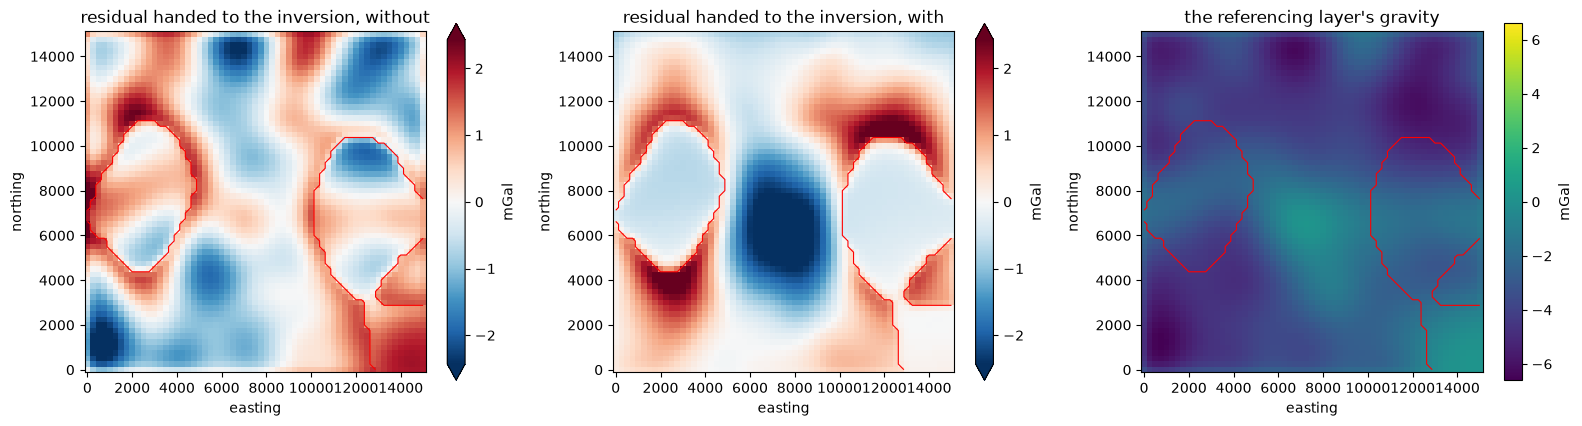

In [21]:
lim = float(np.nanquantile(np.abs(res_start_without), 0.99))
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
res_start_without.plot(
    ax=axes[0], cmap="RdBu_r", vmin=-lim, vmax=lim, cbar_kwargs={"label": "mGal"}
)
axes[0].set_title("residual handed to the inversion, without")
res_start_with.plot(
    ax=axes[1], cmap="RdBu_r", vmin=-lim, vmax=lim, cbar_kwargs={"label": "mGal"}
)
axes[1].set_title("residual handed to the inversion, with")
data_with.ref_grav.plot(ax=axes[2], cmap="viridis", cbar_kwargs={"label": "mGal"})
axes[2].set_title("the referencing layer's gravity")
for ax in axes:
    mark_outcrop(ax)
    ax.set_aspect("equal")
plt.tight_layout()

And the recovered basements (red contours are the outcrops, correct in both since they were baked into the start).
Without the referencing layer the basin is contaminated by topography-shaped basement relief; with it, the recovery matches the truth.
The error maps make the diagnosis quantitative: over the *buried* cells the "without" error correlates strongly with the terrain texture, the "with" error does not. The RMS is reported over the buried region too - the outcrops are known, so including them would only flatter both numbers.

without the layer: buried basement error rms = 107 m, correlation with terrain texture r = -0.95
with the layer: buried basement error rms = 40 m, correlation with terrain texture r = -0.13


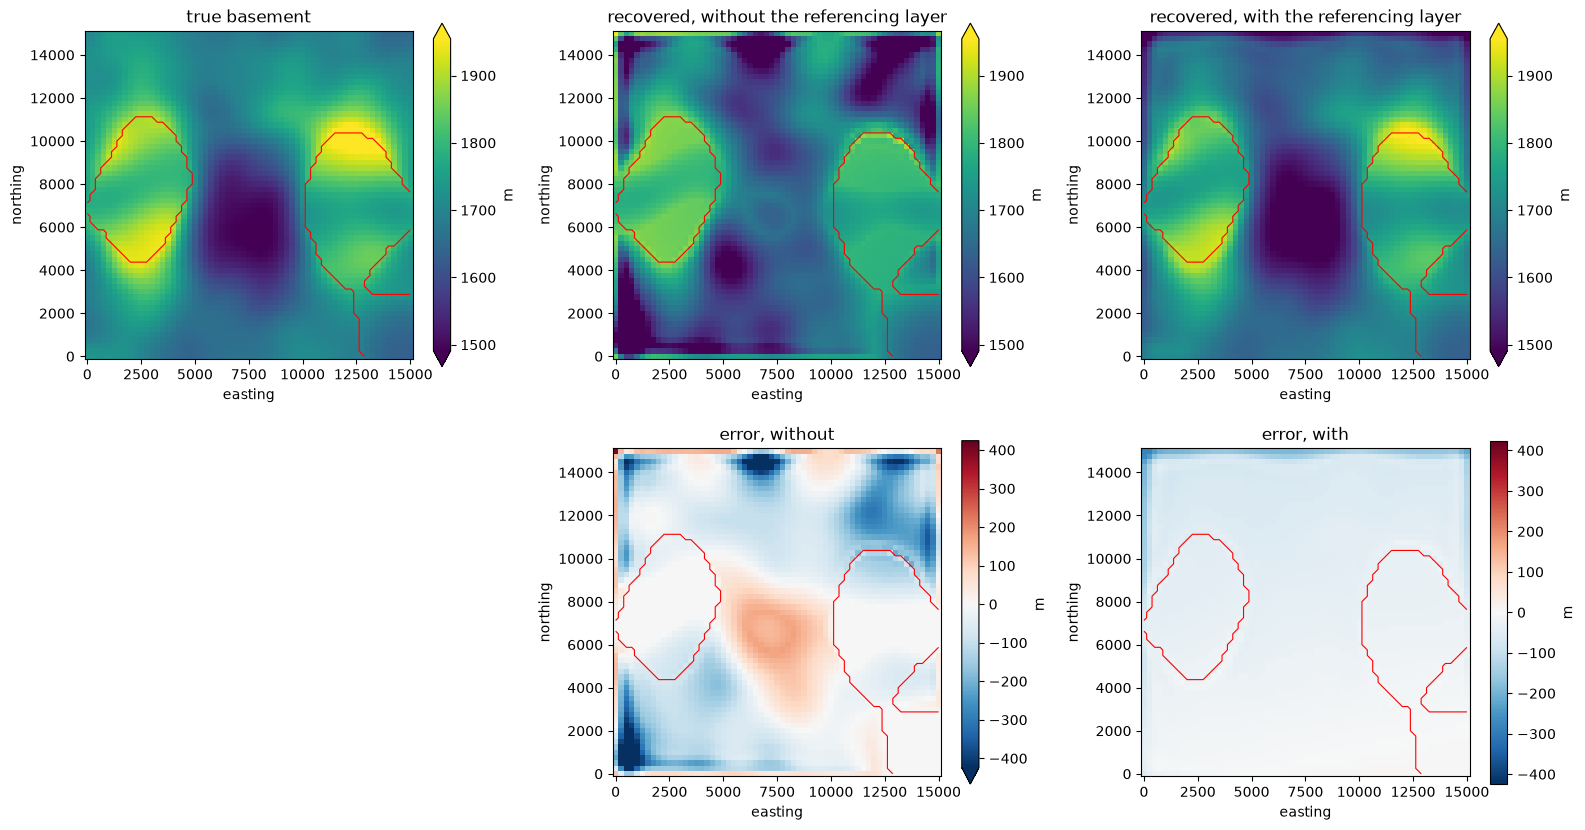

In [22]:
recovered_without = inv_without.model.topography
recovered_with = inv_with.model.topography

vmin, vmax = np.nanquantile(basement, [0.01, 0.99])
err_without = recovered_without - basement
err_with = recovered_with - basement
err_lim = float(np.nanquantile(np.abs(err_without), 0.99))

fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
basement.plot(ax=axes[0, 0], vmin=vmin, vmax=vmax, cbar_kwargs={"label": "m"})
axes[0, 0].set_title("true basement")
recovered_without.plot(ax=axes[0, 1], vmin=vmin, vmax=vmax, cbar_kwargs={"label": "m"})
axes[0, 1].set_title("recovered, without the referencing layer")
recovered_with.plot(ax=axes[0, 2], vmin=vmin, vmax=vmax, cbar_kwargs={"label": "m"})
axes[0, 2].set_title("recovered, with the referencing layer")

axes[1, 0].axis("off")
err_without.plot(
    ax=axes[1, 1],
    cmap="RdBu_r",
    vmin=-err_lim,
    vmax=err_lim,
    cbar_kwargs={"label": "m"},
)
axes[1, 1].set_title("error, without")
err_with.plot(
    ax=axes[1, 2],
    cmap="RdBu_r",
    vmin=-err_lim,
    vmax=err_lim,
    cbar_kwargs={"label": "m"},
)
axes[1, 2].set_title("error, with")
for ax in axes.ravel():
    if ax.has_data():
        mark_outcrop(ax)
        ax.set_aspect("equal")
plt.tight_layout()

# statistics over the buried cells of the inner region (exclude the buffer's prism-edge
# effects and the known outcrops)
inner = data_with.attrs["inner_region"]


def _buried_inner(da):
    d = da.sel(easting=slice(inner[0], inner[1]), northing=slice(inner[2], inner[3]))
    keep = ~outcrop.sel(easting=d.easting, northing=d.northing)
    return d.values[keep.values]


smooth = ground.copy(data=scipy.ndimage.gaussian_filter(ground.values, sigma=12))
terrain = ground - smooth
t = _buried_inner(terrain)
for name, err in (("without", err_without), ("with", err_with)):
    e = _buried_inner(err)
    r = float(np.corrcoef(e, t)[0, 1])
    rms = float(np.sqrt(np.nanmean(e**2)))
    print(
        f"{name} the layer: buried basement error rms = {rms:.0f} m, "
        f"correlation with terrain texture r = {r:.2f}"
    )

## An equivalent shortcut: zref = topography

Everything above used a flat scalar zref and subtracted the referencing layer.
But zref can be *any* surface, and there is one choice that removes the referencing layer entirely: set it equal to the ground.
Then `f(-dp, zref -> ground)` spans zero thickness and vanishes, and the model term `f(+dp, zref -> basement)` becomes `f(-dp, ground -> basement)` - the whole CBGA source.
So with **zref = topography** there is nothing to subtract: you invert the complete Bouguer anomaly directly, the terrain is accounted for because the reference surface carries it, and the unknown is effectively the sediment thickness (prisms hung from the terrain down to the basement).

This is not a rival method - it is the limiting case of the same bookkeeping. Let's confirm it lands in the same place.

In [23]:
# with zref = the ground, the referencing layer has zero thickness -> zero gravity
ref_at_topo = invert4geom.create_model(
    zref=ground,
    density_contrast=-density_contrast,
    topography=xr.Dataset({"upward": ground}),
)
_check = make_data()
_check.inv.forward_gravity(ref_at_topo, name="ref_grav")
print(
    f"referencing layer at zref=ground: max|gravity| = "
    f"{float(np.abs(_check.ref_grav).max()):.1e} mGal"
)

# invert the CBGA directly, with zref = the ground surface (no subtraction), reusing
# the same trend regional and baked-outcrop start via make_model(reference=ground)
data_topo = make_data()
inv_topo, _ = separate_and_invert(data_topo, make_model(reference=ground))
recovered_topo = inv_topo.model.topography
print(inv_topo.termination_reason, f"final RMSE {inv_topo.rmse:.3f} mGal")

referencing layer at zref=ground: max|gravity| = 0.0e+00 mGal
['l2-norm tolerance'] final RMSE 0.019 mGal


flat zref + ref layer: buried basement error rms = 40 m
zref = topography    : buried basement error rms = 41 m
difference between the two: rms = 3.1 m, max = 18 m


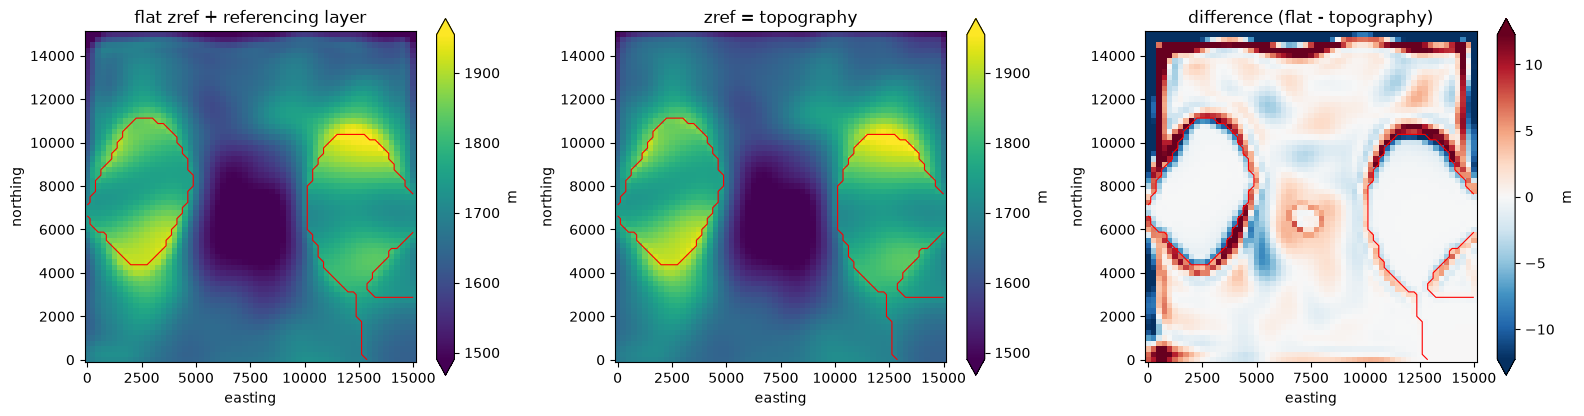

In [24]:
def _inner(da):
    return da.sel(easting=slice(inner[0], inner[1]), northing=slice(inner[2], inner[3]))


diff = recovered_with - recovered_topo
vmin, vmax = np.nanquantile(basement, [0.01, 0.99])
dlim = max(float(np.nanquantile(np.abs(_inner(diff)), 0.99)), 1.0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
recovered_with.plot(ax=axes[0], vmin=vmin, vmax=vmax, cbar_kwargs={"label": "m"})
axes[0].set_title("flat zref + referencing layer")
recovered_topo.plot(ax=axes[1], vmin=vmin, vmax=vmax, cbar_kwargs={"label": "m"})
axes[1].set_title("zref = topography")
diff.plot(ax=axes[2], cmap="RdBu_r", vmin=-dlim, vmax=dlim, cbar_kwargs={"label": "m"})
axes[2].set_title("difference (flat - topography)")
for ax in axes:
    mark_outcrop(ax)
    ax.set_aspect("equal")
plt.tight_layout()

for name, rec in (
    ("flat zref + ref layer", recovered_with),
    ("zref = topography    ", recovered_topo),
):
    e = _buried_inner(rec - basement)
    print(f"{name}: buried basement error rms = {np.sqrt(np.nanmean(e**2)):.0f} m")
d = _buried_inner(diff)
print(
    f"difference between the two: rms = {np.sqrt(np.nanmean(d**2)):.1f} m, "
    f"max = {np.nanmax(np.abs(d)):.0f} m"
)

The two recoveries are the same basement to within a few meters - discretization and regularization-path noise, not physics.

Which to reach for is convenience, not correctness:

- **zref = topography** needs no separate layer to build, pad, and subtract; the terrain correction is automatic and impossible to forget, and the unknown is the sediment thickness directly. The cost: zref is a rugged surface, so the prisms span the full sediment column (larger starting forward gravity, and tall prisms suit the `finite_difference` Jacobian better than the default annulus), and there is no flat datum to lean on for regional separation.
- **flat zref + referencing layer** keeps a flat scalar datum: compact prisms, a small residual that is just the basin, and a zref you can *tune* with reference-level or zref/density cross-validation. The cost is the extra build-pad-subtract step.

For a workflow that optimizes zref and density, or that wants a clean flat datum for the regional, the flat-zref route is more flexible; for the fewest moving parts, zref = topography is hard to beat.

## Takeaways

- a complete Bouguer anomaly's local source is the fill between the **basement and the ground** (assuming the reduction density equals the basement density); a geometry inversion models the layer between **zref and the basement**. The difference, `f(-dp, zref -> ground)`, is the referencing layer
- the referencing layer is fixed, so forward model it once (`create_model` with a *negative* density contrast and the ground as topography) and subtract it from the observed anomaly
- the forward split is exact for *any* zref (verified above to numerical precision), so with the layer included the inversion is largely insensitive to the zref you pick - it becomes a modelling convenience rather than a physical choice. Without the layer, the missing term changes with zref and its terrain texture masquerades as basement relief (~60 m per mGal for a 400 kg/m3 contrast, on broad features)
- build the layer's topography from a DEM padded well beyond the gravity data, to keep its truncation edge effects out of the area of interest
- `zref = topography` is the same bookkeeping with the referencing layer taken to zero thickness: you invert the CBGA directly and solve for sediment thickness. Same result (confirmed above), trading the flat tunable datum for fewer steps
- the terrain texture is the dangerous part: no smooth regional removes it (the demo estimates a genuine planar regional with a trend and the artifact still survives), and it anti-correlates with topography (deeper basement under hills). Subtract the layer rather than hoping the regional catches it
- keep the referencing layer separate from the regional: subtract the layer *first* (it is known and terrain-shaped), then estimate the regional from what remains (deep and smooth). The referencing layer is not something a regional method should be asked to absorb
- it works the same with real complications - a rougher basement, a partially outcropping basement, and an added regional field all leave the referencing-layer artifact intact until the layer is subtracted; the outcrops double as known-basement points that anchor the recovery
- an alternative is to invert the free-air anomaly, which avoids subtracting this low-contrast layer but instead requires forward modelling the full high-density rock column from zref to the ground (2,670 below the basement surface, 2,270 above it) - a much larger dynamic range. The CBGA-plus-referencing-layer route keeps amplitudes small and reuses standard reduced products